# Exploratory Data Analysis (EDA)

## Objective

The objective of this notebook is to perform an initial exploration of the collected dataset for the **Real vs Screen Recapture Detection** task.

This analysis helps verify the integrity of the dataset before feature engineering and model development.

The notebook covers:

- Loading the required libraries
- Defining dataset paths
- Counting images in each class
- Detecting corrupted image files
- Analyzing image dimensions
- Visualizing sample images
- Summarizing the dataset

## Import Required Libraries

Import all libraries required for data loading, visualization, image processing, and numerical analysis throughout the exploratory data analysis.

In [11]:
import os
import cv2
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

plt.style.use("ggplot")

## Define Dataset Paths

Specify the directory paths for the two image classes:

- Real photographs
- Screen recapture photographs

In [12]:
REAL_DIR = "../dataset/real"
SCREEN_DIR = "../dataset/screen"

## Count Dataset Images

Retrieve all valid image files from each directory and calculate the total number of images available in both classes.

This also verifies that the dataset is balanced.

In [13]:
IMAGE_EXTENSIONS = (".jpg", ".jpeg", ".png")

real_images = [
    f for f in os.listdir(REAL_DIR)
    if f.lower().endswith(IMAGE_EXTENSIONS)
]

screen_images = [
    f for f in os.listdir(SCREEN_DIR)
    if f.lower().endswith(IMAGE_EXTENSIONS)
]

print(f"Real Images   : {len(real_images)}")
print(f"Screen Images : {len(screen_images)}")

Real Images   : 51
Screen Images : 51


## Verify Image Integrity

Define a helper function that scans every image in the dataset and checks whether any files are corrupted or unreadable.

This step ensures only valid images are used during training.

In [14]:
def check_images(folder):
    bad = []

    for file in os.listdir(folder):

        if not file.lower().endswith(IMAGE_EXTENSIONS):
            continue

        path = os.path.join(folder, file)

        try:
            Image.open(path).verify()

        except Exception:
            bad.append(file)

    return bad

## Detect Corrupted Images

Run the validation function on both folders to identify any damaged image files before further processing.

In [15]:
print(check_images(REAL_DIR))
print(check_images(SCREEN_DIR))

[]
[]


## Analyze Image Dimensions

Create a helper function to extract the width and height of every image.

Understanding the resolution distribution helps determine an appropriate resizing strategy for deep learning models.

In [16]:
def image_sizes(folder):

    widths = []
    heights = []

    for file in os.listdir(folder):

        if not file.lower().endswith(IMAGE_EXTENSIONS):
            continue

        img = Image.open(os.path.join(folder, file))

        w, h = img.size

        widths.append(w)
        heights.append(h)

    return widths, heights

## Image Size Statistics

Compute and display the minimum and maximum image dimensions for both classes.

These statistics provide an overview of the variability in image resolutions.

In [17]:
real_w, real_h = image_sizes(REAL_DIR)
screen_w, screen_h = image_sizes(SCREEN_DIR)

print("Real Width Range :", min(real_w), "-", max(real_w))
print("Real Height Range:", min(real_h), "-", max(real_h))

print()

print("Screen Width Range :", min(screen_w), "-", max(screen_w))
print("Screen Height Range:", min(screen_h), "-", max(screen_h))

Real Width Range : 720 - 4160
Real Height Range: 720 - 4080

Screen Width Range : 720 - 1600
Screen Height Range: 725 - 1600


## Visualize Sample Real Photographs

Randomly display a subset of genuine photographs to understand the diversity of objects, lighting conditions, viewpoints, and backgrounds present in the dataset.

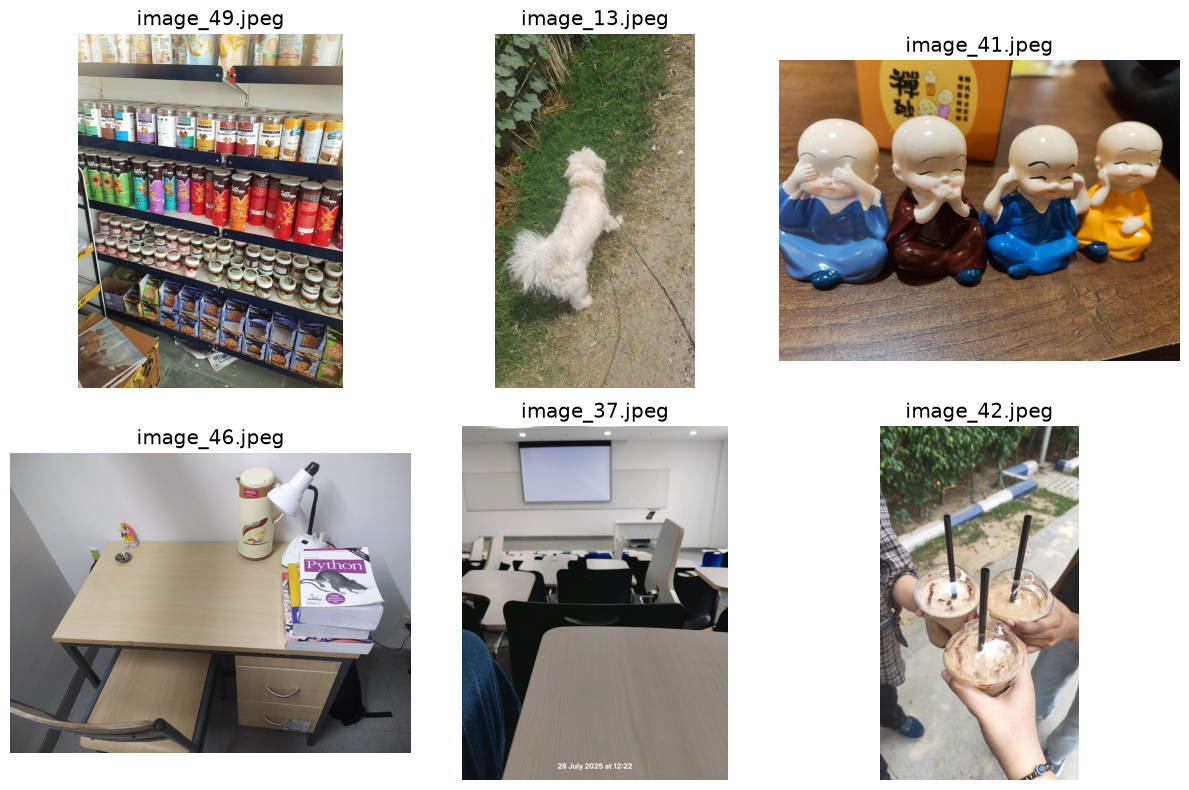

In [21]:
fig, axes = plt.subplots(2,3, figsize=(12,8))

for ax in axes.flat:

    img_name = random.choice(real_images)

    img = Image.open(os.path.join(REAL_DIR, img_name))

    ax.imshow(img)
    ax.set_title(img_name)
    ax.axis("off")

plt.tight_layout()

## Dataset Summary

Create a concise summary table showing the number of images available in each class.

This confirms that the dataset is balanced before model training.

In [19]:
summary = pd.DataFrame({
    "Class": ["Real", "Screen"],
    "Images": [len(real_images), len(screen_images)]
})

summary

,Class,Images
0,Real,51
1,Screen,51


## Visualize Screen Recapture Images

Display randomly selected screen recapture photographs to observe common artifacts such as reflections, display boundaries, pixel grids, and moiré patterns.

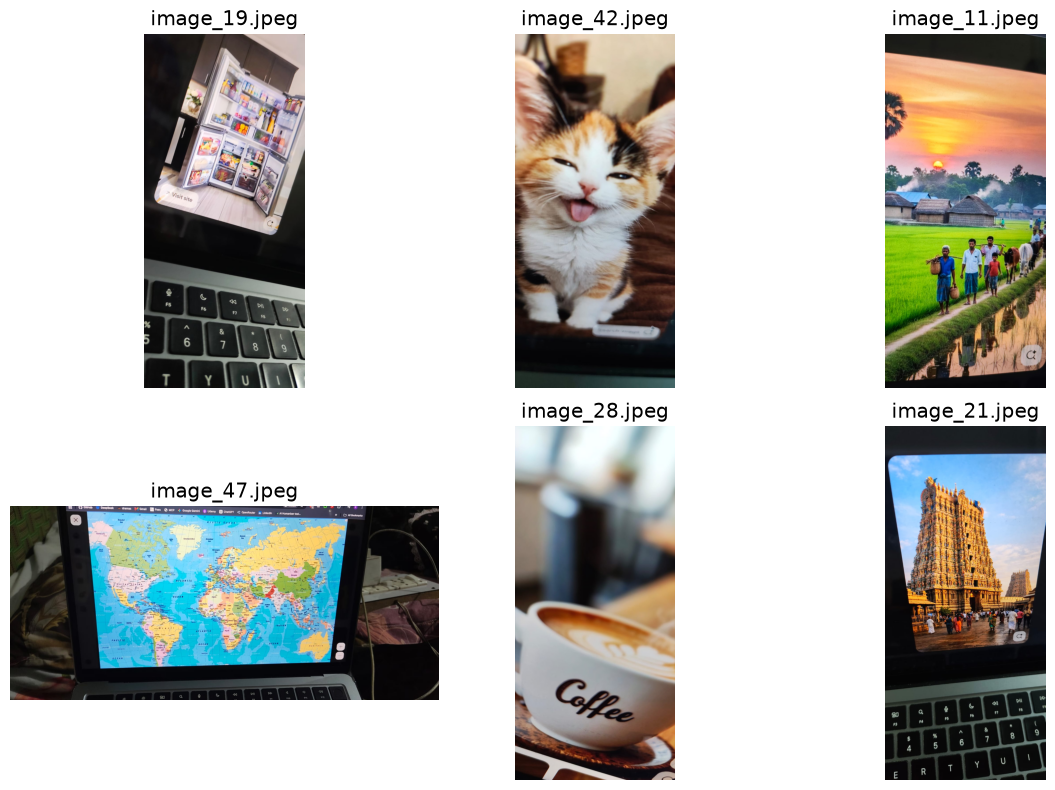

In [22]:
fig, axes = plt.subplots(2,3, figsize=(12,8))

for ax in axes.flat:

    img_name = random.choice(screen_images)

    img = Image.open(os.path.join(SCREEN_DIR, img_name))

    ax.imshow(img)
    ax.set_title(img_name)
    ax.axis("off")

plt.tight_layout()

# Summary

This notebook performed the initial exploratory analysis of the dataset.

### Key observations

- Successfully loaded the dataset.
- Verified that no corrupted images were present.
- Confirmed that the dataset is balanced with equal numbers of real and screen recapture images.
- Analyzed image resolutions to determine preprocessing requirements.
- Visualized representative samples from both classes.
- Established a clean and reliable dataset for subsequent feature engineering and model training.

The dataset is now ready for the next stage: handcrafted feature extraction.